# Visual Grounding: ViT-Base vs ConvNeXtV2-Base
Train and compare two vision backbones on RefCOCO dataset

In [ ]:
# !gdown 1j_HCgvO4yOJ59Eti1ME2GCcKU_yRh-Ot
# !unzip refcoco.zip -d data
!pip -qq install lmdb

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from transformers import BertTokenizer, BertModel
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import lmdb
import pickle
import io
from tqdm import tqdm
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
import os
import pickle

# Utility: Cache LMDB keys for faster access
def cache_lmdb_keys(lmdb_path, output_path=None):
    """
    Extract và cache tất cả keys từ LMDB vào file pickle.
    Chỉ cache các entries là dict (bỏ qua metadata như __len__, __keys__).
    Lần sau sẽ load từ file thay vì phải quét lại.

    Args:
        lmdb_path: đường dẫn tới file LMDB
        output_path: đường dẫn lưu file keys (default: lmdb_path + '.keys.pkl')

    Returns:
        list of keys (chỉ các entries là dict)
    """
    if output_path is None:
        output_path = str(lmdb_path) + '.keys.pkl'

    # Nếu file keys đã tồn tại, load từ file
    if os.path.exists(output_path):
        print(f'Loading cached keys from {output_path}...')
        with open(output_path, 'rb') as f:
            keys = pickle.load(f)
        print(f'Loaded {len(keys)} keys')
        return keys

    # Quét LMDB một lần duy nhất để lấy tất cả keys (chỉ dict entries)
    print(f'Extracting keys from {lmdb_path}...')
    env = lmdb.open(
        str(lmdb_path),
        readonly=True,
        lock=False,
        readahead=False,
        meminit=False,
        subdir=False
    )

    keys = []
    with env.begin(write=False) as txn:
        cursor = txn.cursor()
        for key, value in cursor:
            # Filter: chỉ lấy các entries là dict (bỏ qua metadata)
            data = pickle.loads(value)
            if isinstance(data, dict):
                keys.append(key)

    env.close()

    # Lưu keys vào file
    with open(output_path, 'wb') as f:
        pickle.dump(keys, f)

    print(f'Cached {len(keys)} keys to {output_path}')
    return keys

In [ ]:
# Temporary dataset for data analysis
class TempDataset(Dataset):
    def __init__(self, lmdb_path):
        self.lmdb_path = lmdb_path
        self.env = None

        # Cache keys từ LMDB (chỉ quét 1 lần thay vì mỗi lần gọi __getitem__)
        self.keys = cache_lmdb_keys(lmdb_path)
        self.length = len(self.keys)

    def _init_env(self):
        if self.env is None:
            self.env = lmdb.open(str(self.lmdb_path), readonly=True, lock=False, readahead=False, meminit=False, subdir=False)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        self._init_env()

        # Sử dụng key từ cache để truy cập (O(1))
        key = self.keys[idx]

        with self.env.begin(write=False) as txn:
            value = txn.get(key)
            if value is None:
                raise IndexError(f"Key {key} not found")
            data = pickle.loads(value)

        # Xử lý dữ liệu từ LMDB
        if not isinstance(data, dict):
            raise ValueError(f"Expected dict, got {type(data)}")

        img = Image.open(io.BytesIO(data['img'])).convert('RGB')
        orig_w, orig_h = img.size
        mask = Image.open(io.BytesIO(data['mask']))
        mask_array = np.array(mask)

        ys, xs = np.where(mask_array > 0)
        if len(xs) > 0:
            x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
        else:
            x1, y1, x2, y2 = 0, 0, orig_w, orig_h

        bbox = [x1 / orig_w, y1 / orig_h, x2 / orig_w, y2 / orig_h]

        sents = data['sents']
        text = random.choice(sents) if isinstance(sents, list) else sents

        return {'text': text, 'bbox': bbox}

temp_dataset = TempDataset(Path('./data/lmdb/refcoco/train.lmdb'))
print(f'Train samples: {len(temp_dataset)}')

Loading cached keys from data/lmdb/refcoco/train.lmdb.keys.pkl...
Loaded 42404 keys
Train samples: 42404


Sampling 2000 bboxes...


100%|██████████| 2000/2000 [00:13<00:00, 153.41it/s]


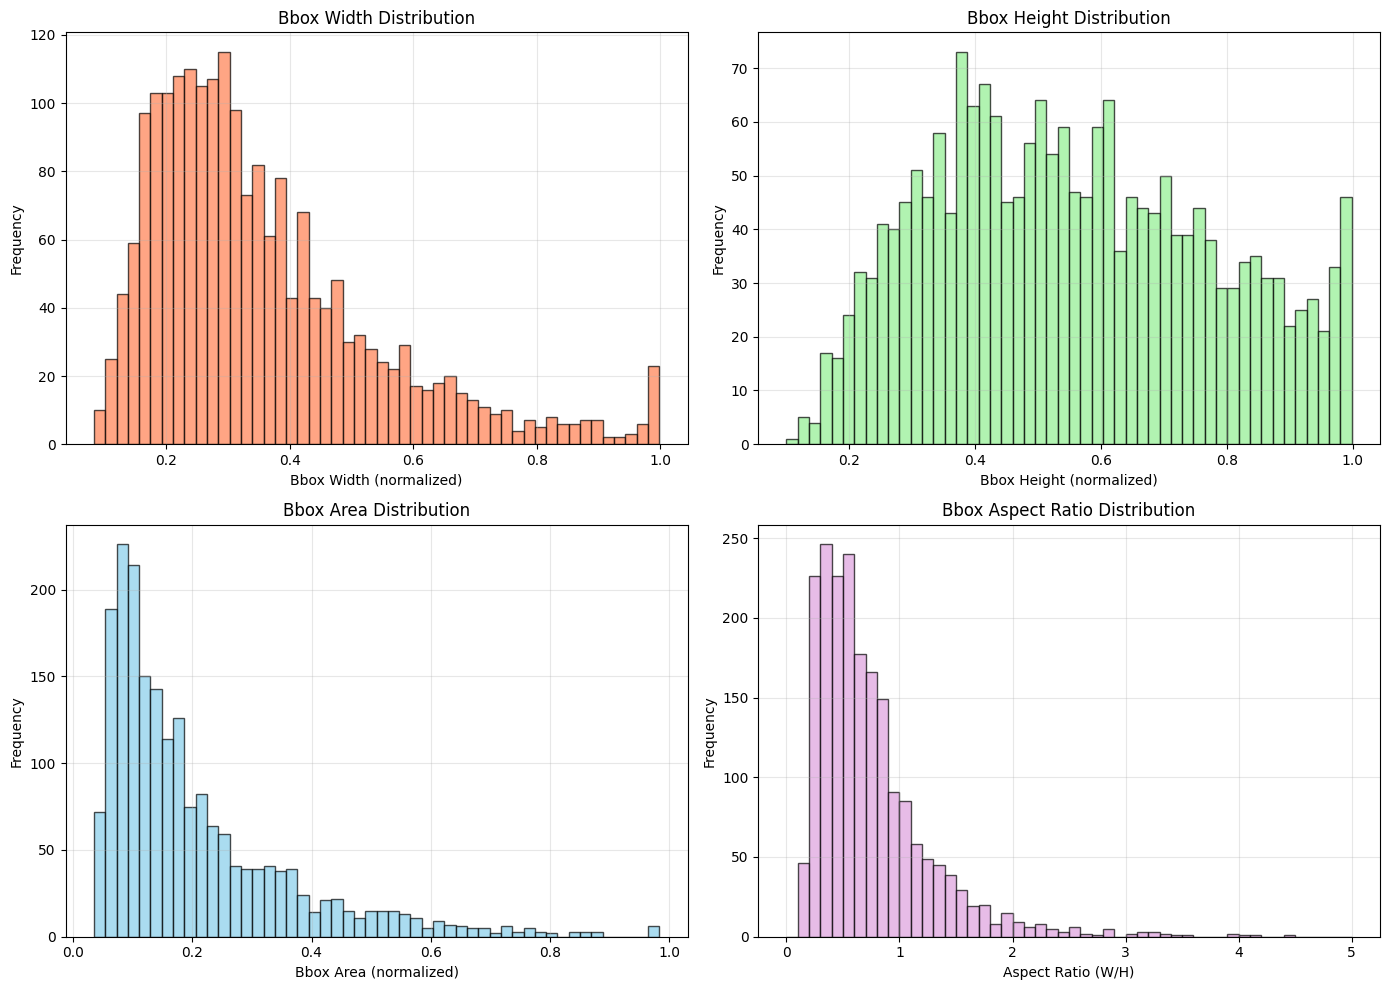


Bbox Statistics:
Width - Mean: 0.354, Std: 0.184
Height - Mean: 0.555, Std: 0.219
Area - Mean: 0.204, Std: 0.159
Aspect Ratio - Mean: 0.756, Median: 0.609

Object Size Distribution:
Small (area < 0.1): 29.1%
Medium (0.1 <= area < 0.5): 64.2%
Large (area >= 0.5): 6.7%


In [ ]:
# Analyze bbox distribution
bbox_widths = []
bbox_heights = []
bbox_areas = []
aspect_ratios = []

print('Sampling 2000 bboxes...')
indices = random.sample(range(len(temp_dataset)), min(2000, len(temp_dataset)))

for idx in tqdm(indices):
    sample = temp_dataset[idx]
    bbox = sample['bbox']

    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]
    area = w * h

    bbox_widths.append(w)
    bbox_heights.append(h)
    bbox_areas.append(area)
    aspect_ratios.append(w / (h + 1e-6))

bbox_widths = np.array(bbox_widths)
bbox_heights = np.array(bbox_heights)
bbox_areas = np.array(bbox_areas)
aspect_ratios = np.array(aspect_ratios)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(bbox_widths, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].set_xlabel('Bbox Width (normalized)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Bbox Width Distribution')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(bbox_heights, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_xlabel('Bbox Height (normalized)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Bbox Height Distribution')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(bbox_areas, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].set_xlabel('Bbox Area (normalized)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Bbox Area Distribution')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(aspect_ratios, bins=50, range=(0, 5), edgecolor='black', alpha=0.7, color='plum')
axes[1, 1].set_xlabel('Aspect Ratio (W/H)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Bbox Aspect Ratio Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nBbox Statistics:')
print(f'Width - Mean: {bbox_widths.mean():.3f}, Std: {bbox_widths.std():.3f}')
print(f'Height - Mean: {bbox_heights.mean():.3f}, Std: {bbox_heights.std():.3f}')
print(f'Area - Mean: {bbox_areas.mean():.3f}, Std: {bbox_areas.std():.3f}')
print(f'Aspect Ratio - Mean: {aspect_ratios.mean():.3f}, Median: {np.median(aspect_ratios):.3f}')

small_objects = (bbox_areas < 0.1).sum() / len(bbox_areas) * 100
medium_objects = ((bbox_areas >= 0.1) & (bbox_areas < 0.5)).sum() / len(bbox_areas) * 100
large_objects = (bbox_areas >= 0.5).sum() / len(bbox_areas) * 100

print(f'\nObject Size Distribution:')
print(f'Small (area < 0.1): {small_objects:.1f}%')
print(f'Medium (0.1 <= area < 0.5): {medium_objects:.1f}%')
print(f'Large (area >= 0.5): {large_objects:.1f}%')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Sampling 2000 sentences...


100%|██████████| 2000/2000 [00:12<00:00, 156.32it/s]


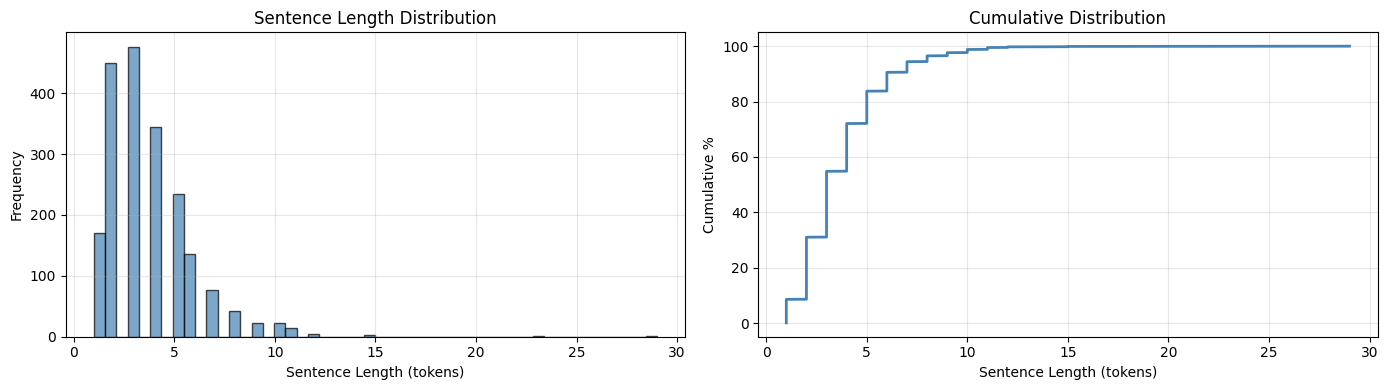


Sentence Length Statistics:
Mean: 3.7
Std: 2.2
Min: 1
Max: 29
50th percentile: 3
75th percentile: 5
90th percentile: 6
95th percentile: 8
99th percentile: 11
100th percentile: 29

Recommended max_text_len:
  8 tokens -> covers 96.5%
  11 tokens -> covers 99.5%


In [ ]:
# Analyze sentence length
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
sentence_lengths = []

print('Sampling 2000 sentences...')
indices = random.sample(range(len(temp_dataset)), min(2000, len(temp_dataset)))

for idx in tqdm(indices):
    sample = temp_dataset[idx]
    text = sample['text']
    tokens = tokenizer.tokenize(text)
    sentence_lengths.append(len(tokens))

sentence_lengths = np.array(sentence_lengths)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sentence_lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Sentence Length (tokens)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sentence Length Distribution')
axes[0].grid(True, alpha=0.3)

sorted_lengths = np.sort(sentence_lengths)
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
axes[1].plot(sorted_lengths, cumulative, linewidth=2, color='steelblue')
axes[1].set_xlabel('Sentence Length (tokens)')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

percentiles = [50, 75, 90, 95, 99, 100]
print('\nSentence Length Statistics:')
print(f'Mean: {sentence_lengths.mean():.1f}')
print(f'Std: {sentence_lengths.std():.1f}')
print(f'Min: {sentence_lengths.min()}')
print(f'Max: {sentence_lengths.max()}')
for p in percentiles:
    val = np.percentile(sentence_lengths, p)
    print(f'{p}th percentile: {val:.0f}')

print('\nRecommended max_text_len:')
for p in [95, 99]:
    val = int(np.percentile(sentence_lengths, p))
    coverage = (sentence_lengths <= val).sum() / len(sentence_lengths) * 100
    print(f'  {val} tokens -> covers {coverage:.1f}%')

## Configuration

In [ ]:
class Config:
    data_dir = './data'
    lmdb_dir = './data/lmdb/refcoco'

    img_size = 224
    max_text_len = 16  # Adjust based on analysis above

    batch_size = 128
    num_workers = 0  # Set to 0 for LMDB stability
    num_epochs = 20
    learning_rate = 1e-3

    hidden_dim = 256
    text_encoder = 'bert-base-uncased'

config = Config()

## Dataset Class with LMDB

In [ ]:
class RefCOCODatasetLMDB(Dataset):
    def __init__(self, lmdb_path, config, transform=None):
        self.lmdb_path = lmdb_path
        self.config = config
        self.transform = transform
        self.env = None

        # Cache keys từ LMDB (chỉ quét 1 lần)
        self.keys = cache_lmdb_keys(lmdb_path)
        self.length = len(self.keys)

        # Text tokenizer
        self.tokenizer = BertTokenizer.from_pretrained(config.text_encoder)

    def _init_env(self):
        """Lazy initialization for multiprocessing."""
        if self.env is None:
            self.env = lmdb.open(
                str(self.lmdb_path),
                readonly=True,
                lock=False,
                readahead=False,
                meminit=False,
                subdir=False
            )

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        self._init_env()

        # Trực tiếp sử dụng key từ cache thay vì phải iterate
        key = self.keys[idx]

        with self.env.begin(write=False) as txn:
            value = txn.get(key)
            if value is None:
                raise IndexError(f"Key {key} not found in LMDB")
            data = pickle.loads(value)

        # Decode image from JPEG bytes
        img = Image.open(io.BytesIO(data['img'])).convert('RGB')
        orig_w, orig_h = img.size

        # Get random sentence
        sents = data['sents']
        text = random.choice(sents) if isinstance(sents, list) else sents

        # Decode mask for bbox (use mask to compute bbox)
        mask = Image.open(io.BytesIO(data['mask']))
        mask_array = np.array(mask)

        # Compute bbox from mask
        ys, xs = np.where(mask_array > 0)
        if len(xs) > 0:
            x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
        else:
            x1, y1, x2, y2 = 0, 0, orig_w, orig_h

        # Normalize bbox to [0, 1]
        bbox = torch.tensor([
            x1 / orig_w,
            y1 / orig_h,
            x2 / orig_w,
            y2 / orig_h
        ], dtype=torch.float32)

        # Transform image
        if self.transform:
            img = self.transform(img)

        # Tokenize text
        text_inputs = self.tokenizer(
            text,
            max_length=self.config.max_text_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'image': img,
            'input_ids': text_inputs['input_ids'].squeeze(0),
            'attention_mask': text_inputs['attention_mask'].squeeze(0),
            'bbox': bbox,
            'text': text,
            'img_name': data['img_name']
        }

## Data Loading and Visualization

In [ ]:
# Create transforms
# CRITICAL FIX: Use simple Resize + Normalize ONLY (no crop!)
# timm.data.create_transform may use center crop which breaks bbox alignment
from torchvision import transforms as T

transform = T.Compose([
    T.Resize((config.img_size, config.img_size), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = T.Compose([
    T.Resize((config.img_size, config.img_size), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = RefCOCODatasetLMDB(
    Path(config.lmdb_dir) / 'train.lmdb',
    config,
    transform=transform
)

val_dataset = RefCOCODatasetLMDB(
    Path(config.lmdb_dir) / 'val.lmdb',
    config,
    transform=transform_val
)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')

# Create dataloaders (reusable for both models)
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')

Loading cached keys from data/lmdb/refcoco/train.lmdb.keys.pkl...
Loaded 42404 keys


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading cached keys from data/lmdb/refcoco/val.lmdb.keys.pkl...
Loaded 3811 keys
Train samples: 42404
Val samples: 3811
Train batches: 332
Val batches: 30



TEST 3: BEFORE vs AFTER TRANSFORM COMPARISON
Loading cached keys from data/lmdb/refcoco/train.lmdb.keys.pkl...
Loaded 42404 keys


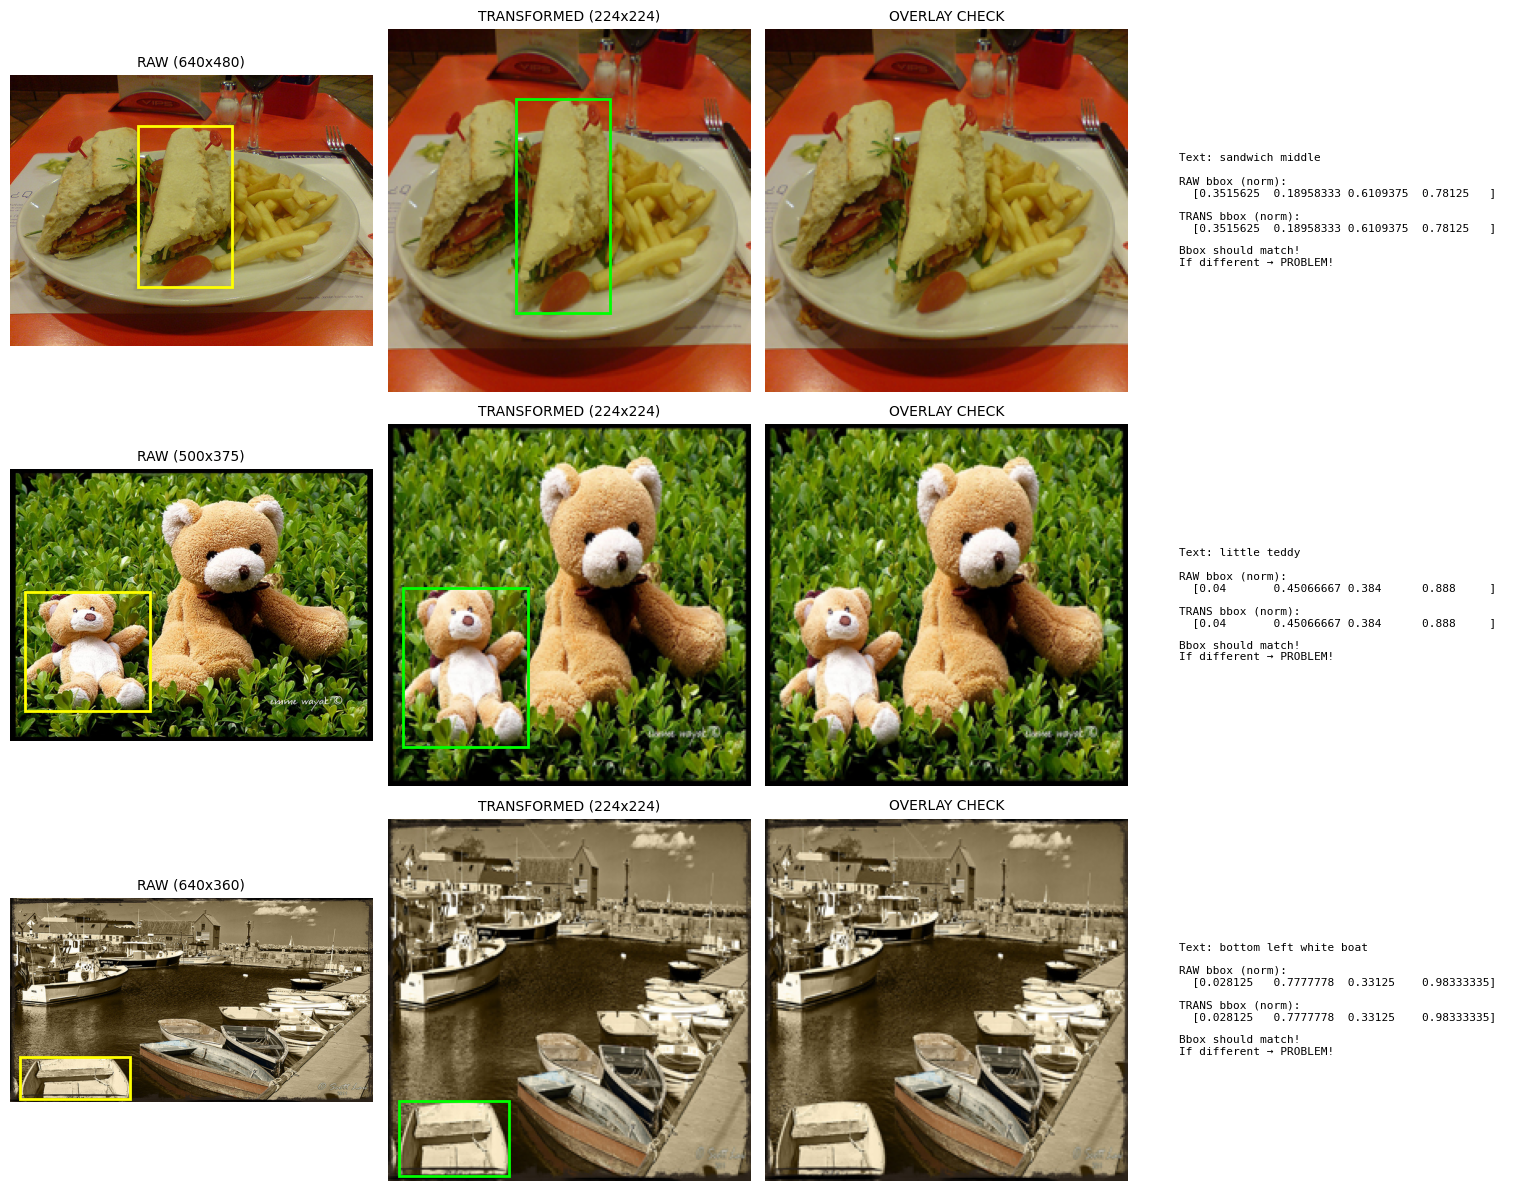

In [ ]:
# Test 3: So sánh bbox TRƯỚC và SAU transform (Deep verification)
print('\n' + '=' * 60)
print('TEST 3: BEFORE vs AFTER TRANSFORM COMPARISON')
print('=' * 60)

# Dataset KHÔNG transform (để xem ảnh + bbox gốc)
raw_test_dataset = RefCOCODatasetLMDB(
    Path(config.lmdb_dir) / 'train.lmdb',
    config,
    transform=None
)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(3):
    idx = random.randint(0, len(raw_test_dataset) - 1)

    # Sample TRƯỚC transform (raw)
    raw_sample = raw_test_dataset[idx]
    raw_img = np.array(raw_sample['image'])
    raw_h, raw_w = raw_img.shape[:2]
    raw_bbox = raw_sample['bbox'].numpy()
    raw_x1, raw_y1, raw_x2, raw_y2 = raw_bbox[0]*raw_w, raw_bbox[1]*raw_h, raw_bbox[2]*raw_w, raw_bbox[3]*raw_h

    # Sample SAU transform (from train_dataset)
    transformed_sample = train_dataset[idx]
    trans_img = transformed_sample['image'].permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    trans_img = trans_img * std + mean
    trans_img = np.clip(trans_img, 0, 1)
    trans_bbox = transformed_sample['bbox'].numpy()
    trans_x1, trans_y1, trans_x2, trans_y2 = trans_bbox * config.img_size

    # Plot RAW image
    axes[i, 0].imshow(raw_img)
    rect = patches.Rectangle(
        (raw_x1, raw_y1), raw_x2 - raw_x1, raw_y2 - raw_y1,
        linewidth=2, edgecolor='yellow', facecolor='none'
    )
    axes[i, 0].add_patch(rect)
    axes[i, 0].set_title(f'RAW ({raw_w}x{raw_h})', fontsize=10)
    axes[i, 0].axis('off')

    # Plot TRANSFORMED image
    axes[i, 1].imshow(trans_img)
    rect = patches.Rectangle(
        (trans_x1, trans_y1), trans_x2 - trans_x1, trans_y2 - trans_y1,
        linewidth=2, edgecolor='lime', facecolor='none'
    )
    axes[i, 1].add_patch(rect)
    axes[i, 1].set_title(f'TRANSFORMED ({config.img_size}x{config.img_size})', fontsize=10)
    axes[i, 1].axis('off')

    # Plot OVERLAY (để so sánh trực quan)
    axes[i, 2].imshow(trans_img)
    axes[i, 2].set_title('OVERLAY CHECK', fontsize=10)
    axes[i, 2].axis('off')

    # Text info
    text_info = f"Text: {raw_sample['text'][:50]}\n\n"
    text_info += f"RAW bbox (norm):\n  {raw_bbox}\n\n"
    text_info += f"TRANS bbox (norm):\n  {trans_bbox}\n\n"
    text_info += f"Bbox should match!\n"
    text_info += f"If different → PROBLEM!"
    axes[i, 3].text(0.1, 0.5, text_info, fontsize=8, verticalalignment='center', family='monospace')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('before_after_transform_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Architecture - TransVG Pipeline

In [ ]:
class MLP(nn.Module):
    """Multi-layer perceptron for bbox prediction head."""
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.num_layers = num_layers
        h = [hidden_dim] * (num_layers - 1)
        self.layers = nn.ModuleList(
            nn.Linear(n, k) for n, k in zip([input_dim] + h, h + [output_dim])
        )

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = F.relu(layer(x)) if i < self.num_layers - 1 else layer(x)
        return x

In [ ]:
class VisualLinguisticTransformer(nn.Module):
    """
    Visual-Linguistic Transformer với [REG] token học được.
    Theo paper TransVG: End-to-End Visual Grounding with Transformers
    """
    def __init__(self, d_model, nhead, num_layers, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, tokens, mask=None):
        """
        Args:
            tokens: [B, N, D] - concatenated visual + linguistic tokens + [REG] token
            mask: [B, N] - attention mask
        Returns:
            [B, N, D] - transformed tokens
        """
        out = self.transformer(tokens, src_key_padding_mask=mask)
        out = self.norm(out)
        return out


In [ ]:
class TransVG(nn.Module):
    """
    TransVG: End-to-End Visual Grounding with Transformers
    Simple pipeline following original TransVG repository.
    """
    def __init__(self, backbone_type, config):
        super().__init__()
        self.config = config
        self.backbone_type = backbone_type

        # Vision backbone
        if backbone_type == 'vit':
            self.vision_encoder = timm.create_model(
                'vit_base_patch16_224',
                pretrained=True,
                num_classes=0
            )
            vision_dim = 768
            self.num_visu_token = 196  # 14x14 patches
        elif backbone_type == 'convnext':
            self.vision_encoder = timm.create_model(
                'convnextv2_base.fcmae_ft_in22k_in1k',
                pretrained=True,
                num_classes=0
            )
            vision_dim = 1024
            self.num_visu_token = 49  # 7x7 feature map
        else:
            raise ValueError(f"Unknown backbone: {backbone_type}")

        # Text encoder
        self.text_encoder = BertModel.from_pretrained(config.text_encoder)
        text_dim = 768
        self.num_text_token = config.max_text_len

        # Projection to hidden_dim
        self.vision_proj = nn.Linear(vision_dim, config.hidden_dim)
        self.text_proj = nn.Linear(text_dim, config.hidden_dim)

        # [REG] token
        self.reg_token = nn.Embedding(1, config.hidden_dim)

        # Learned positional embeddings (1 REG + visual + text)
        num_total = 1 + self.num_visu_token + self.num_text_token
        self.vl_pos_embed = nn.Embedding(num_total, config.hidden_dim)

        # VL Transformer
        self.vl_transformer = VisualLinguisticTransformer(
            d_model=config.hidden_dim,
            nhead=8,
            num_layers=4,
            dropout=0.1
        )

        # Bbox head
        self.bbox_head = MLP(config.hidden_dim, config.hidden_dim, 4, 3)

    def forward(self, image, input_ids, attention_mask):
        batch_size = image.shape[0]
        device = image.device

        # Visual features
        if self.backbone_type == 'vit':
            v = self.vision_encoder.forward_features(image)
            if isinstance(v, dict):
                v = v["x"]
            visual_feat = v[:, 1:, :]  # [B, 196, 768]
        elif self.backbone_type == 'convnext':
            v = self.vision_encoder.forward_features(image)
            if isinstance(v, dict):
                v = v["x"]
            B, C, H, W = v.shape
            visual_feat = v.flatten(2).transpose(1, 2)  # [B, H*W, C]

        visual_tokens = self.vision_proj(visual_feat)  # [B, N_v, D]

        # Text features
        text_output = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = self.text_proj(text_output.last_hidden_state)  # [B, L, D]

        # [REG] token
        reg_tokens = self.reg_token.weight.unsqueeze(0).expand(batch_size, -1, -1)  # [B, 1, D]

        # Concat: [REG] + visual + text (standard VL order)
        all_tokens = torch.cat([reg_tokens, visual_tokens, text_tokens], dim=1)  # [B, 1+N_v+L, D]

        # Add positional embeddings
        pos_embed = self.vl_pos_embed.weight.unsqueeze(0).expand(batch_size, -1, -1)
        all_tokens = all_tokens + pos_embed

        # Attention mask: [REG] + visual + text
        reg_mask = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
        visual_mask = torch.zeros(batch_size, self.num_visu_token, dtype=torch.bool, device=device)
        text_mask = ~attention_mask.bool()
        combined_mask = torch.cat([reg_mask, visual_mask, text_mask], dim=1)

        # VL Transformer
        fused_tokens = self.vl_transformer(all_tokens, mask=combined_mask)

        # Predict bbox from [REG] token
        reg_output = fused_tokens[:, 0, :]
        bbox_pred = self.bbox_head(reg_output).sigmoid()

        return bbox_pred

## Training Function

In [ ]:
# ===== Utility Functions =====

def box_area_xyxy(boxes):
    """Compute area of boxes in xyxy format."""
    return (boxes[:, 2] - boxes[:, 0]).clamp(min=0) * (boxes[:, 3] - boxes[:, 1]).clamp(min=0)

def sanitize_xyxy(boxes):
    """
    Sanitize bounding boxes to ensure x1 < x2 and y1 < y2.
    This prevents negative areas and invalid IoU calculations.
    """
    x1 = torch.min(boxes[:, 0], boxes[:, 2])
    y1 = torch.min(boxes[:, 1], boxes[:, 3])
    x2 = torch.max(boxes[:, 0], boxes[:, 2])
    y2 = torch.max(boxes[:, 1], boxes[:, 3])
    return torch.stack([x1, y1, x2, y2], dim=1).clamp(0, 1)

def xyxy2xywh(boxes):
    """Convert boxes from xyxy to xywh format."""
    x1, y1, x2, y2 = boxes.unbind(-1)
    w = x2 - x1
    h = y2 - y1
    cx = x1 + w / 2
    cy = y1 + h / 2
    return torch.stack([cx, cy, w, h], dim=-1)

def xywh2xyxy(boxes):
    """Convert boxes from xywh to xyxy format."""
    cx, cy, w, h = boxes.unbind(-1)
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return torch.stack([x1, y1, x2, y2], dim=-1)

def compute_iou(pred_bbox, gt_bbox):
    """
    Compute IoU between predicted and ground truth bboxes.
    Assumes boxes are in xyxy format and already sanitized.
    """
    x1 = torch.max(pred_bbox[:, 0], gt_bbox[:, 0])
    y1 = torch.max(pred_bbox[:, 1], gt_bbox[:, 1])
    x2 = torch.min(pred_bbox[:, 2], gt_bbox[:, 2])
    y2 = torch.min(pred_bbox[:, 3], gt_bbox[:, 3])

    intersection = torch.clamp(x2 - x1, min=0) * torch.clamp(y2 - y1, min=0)

    pred_area = box_area_xyxy(pred_bbox)
    gt_area = box_area_xyxy(gt_bbox)

    union = pred_area + gt_area - intersection
    iou = intersection / (union + 1e-6)

    return iou

def giou_loss(pred_bbox, gt_bbox, eps=1e-6):
    """
    Compute Generalized IoU loss.
    GIoU = IoU - (C - Union) / C
    where C is the smallest enclosing box.

    Args:
        pred_bbox: [B, 4] predicted boxes in xyxy format (sanitized)
        gt_bbox: [B, 4] ground truth boxes in xyxy format (sanitized)
    Returns:
        GIoU loss scalar
    """
    # Intersection
    x1 = torch.max(pred_bbox[:, 0], gt_bbox[:, 0])
    y1 = torch.max(pred_bbox[:, 1], gt_bbox[:, 1])
    x2 = torch.min(pred_bbox[:, 2], gt_bbox[:, 2])
    y2 = torch.min(pred_bbox[:, 3], gt_bbox[:, 3])
    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    # Areas
    area_pred = box_area_xyxy(pred_bbox)
    area_gt = box_area_xyxy(gt_bbox)
    union = area_pred + area_gt - inter + eps

    # IoU
    iou = inter / union

    # Enclosing box (smallest box containing both pred and gt)
    cx1 = torch.min(pred_bbox[:, 0], gt_bbox[:, 0])
    cy1 = torch.min(pred_bbox[:, 1], gt_bbox[:, 1])
    cx2 = torch.max(pred_bbox[:, 2], gt_bbox[:, 2])
    cy2 = torch.max(pred_bbox[:, 3], gt_bbox[:, 3])
    c_area = (cx2 - cx1).clamp(min=0) * (cy2 - cy1).clamp(min=0) + eps

    # GIoU
    giou = iou - (c_area - union) / c_area

    # GIoU loss
    return (1 - giou).mean()

def train_model(backbone_name, architecture_name, config, train_loader, val_loader):
    print(f'\nTraining with {backbone_name.upper()}')
    print('=' * 50)

    # Create model
    if architecture_name == "concat":
        model = ConcatVG(backbone_name, config).to(device)
    else:
        model = TransVG(backbone_name, config).to(device)

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters: {total_params:,}')
    print(f'Trainable parameters: {trainable_params:,}')

    # Optimizer with parameter groups (different LR for different parts)
    # Optimized LRs: 1e-5 for pretrained encoders, 1e-4 for new layers
    optimizer = torch.optim.AdamW([
        {"params": model.vision_encoder.parameters(), "lr": 1e-5},
        {"params": model.text_encoder.parameters(), "lr": 1e-5},
        {"params": [p for n, p in model.named_parameters()
                    if not n.startswith("vision_encoder") and not n.startswith("text_encoder")],
         "lr": 1e-4},
    ], weight_decay=0.05)

    # Loss functions
    l1_criterion = nn.L1Loss()

    history = {
        'train_loss': [],
        'train_l1': [],
        'train_giou': [],
        'train_iou': [],
        'val_loss': [],
        'val_l1': [],
        'val_giou': [],
        'val_iou': []
    }

    best_iou = 0.0

    for epoch in range(config.num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_l1_sum = 0.0
        train_giou_sum = 0.0
        train_iou_sum = 0.0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{config.num_epochs}')
        for batch_idx, batch in enumerate(pbar):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            gt_bbox = batch['bbox'].to(device)

            # Debug: Check GT bbox range (only once)
            if epoch == 0 and batch_idx == 0:
                print(f'\n[DEBUG] GT bbox range: min={gt_bbox.min().item():.4f}, max={gt_bbox.max().item():.4f}')
                if gt_bbox.max().item() > 1.0:
                    print('[WARNING] GT bbox values exceed 1.0! Check normalization.')

            optimizer.zero_grad()

            # Model prediction (outputs xywh format)
            pred_bbox_xywh = model(images, input_ids, attention_mask)

            # Convert predictions to xyxy and sanitize
            pred_bbox_xyxy = xywh2xyxy(pred_bbox_xywh)
            pred_bbox_xyxy = sanitize_xyxy(pred_bbox_xyxy)

            # Sanitize GT (should already be normalized, but ensure valid)
            gt_bbox_xyxy = sanitize_xyxy(gt_bbox)

            # Convert back to xywh for L1 loss (following TransVG)
            pred_bbox_xywh_clean = xyxy2xywh(pred_bbox_xyxy)
            gt_bbox_xywh = xyxy2xywh(gt_bbox_xyxy)

            # Compute losses
            l1_loss = l1_criterion(pred_bbox_xywh_clean, gt_bbox_xywh)
            giou_loss_val = giou_loss(pred_bbox_xyxy, gt_bbox_xyxy)

            # Total loss: L1 + 2.0 * GIoU (following TransVG paper)
            loss = l1_loss + 2.0 * giou_loss_val

            loss.backward()
            # Gradient clipping (prevents exploding gradients)
            # Set to 0.2 for vision-language stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.2)
            optimizer.step()

            # Compute IoU for monitoring
            iou = compute_iou(pred_bbox_xyxy, gt_bbox_xyxy)

            train_loss += loss.item()
            train_l1_sum += l1_loss.item()
            train_giou_sum += giou_loss_val.item()
            train_iou_sum += iou.mean().item()

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'l1': f'{l1_loss.item():.4f}',
                'giou': f'{giou_loss_val.item():.4f}',
                'iou': f'{iou.mean().item():.4f}'
            })

        train_loss /= len(train_loader)
        train_l1 = train_l1_sum / len(train_loader)
        train_giou = train_giou_sum / len(train_loader)
        train_iou = train_iou_sum / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        val_l1_sum = 0.0
        val_giou_sum = 0.0
        total_iou = 0.0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                gt_bbox = batch['bbox'].to(device)

                # Model prediction (xywh format)
                pred_bbox_xywh = model(images, input_ids, attention_mask)

                # Convert to xyxy and sanitize
                pred_bbox_xyxy = xywh2xyxy(pred_bbox_xywh)
                pred_bbox_xyxy = sanitize_xyxy(pred_bbox_xyxy)
                gt_bbox_xyxy = sanitize_xyxy(gt_bbox)

                # Convert to xywh for L1
                pred_bbox_xywh_clean = xyxy2xywh(pred_bbox_xyxy)
                gt_bbox_xywh = xyxy2xywh(gt_bbox_xyxy)

                # Losses
                l1_loss = l1_criterion(pred_bbox_xywh_clean, gt_bbox_xywh)
                giou_loss_val = giou_loss(pred_bbox_xyxy, gt_bbox_xyxy)
                loss = l1_loss + 2.0 * giou_loss_val

                val_loss += loss.item()
                val_l1_sum += l1_loss.item()
                val_giou_sum += giou_loss_val.item()

                # IoU
                iou = compute_iou(pred_bbox_xyxy, gt_bbox_xyxy)
                total_iou += iou.sum().item()

        val_loss /= len(val_loader)
        val_l1 = val_l1_sum / len(val_loader)
        val_giou = val_giou_sum / len(val_loader)
        val_iou = total_iou / len(val_dataset)

        history['train_loss'].append(train_loss)
        history['train_l1'].append(train_l1)
        history['train_giou'].append(train_giou)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(val_loss)
        history['val_l1'].append(val_l1)
        history['val_giou'].append(val_giou)
        history['val_iou'].append(val_iou)

        # Print epoch summary
        print(f'Epoch {epoch+1}/{config.num_epochs}:')
        print(f'  Train: loss={train_loss:.4f} (L1={train_l1:.4f}, GIoU={train_giou:.4f}), IoU={train_iou:.4f}')
        print(f'  Val:   loss={val_loss:.4f} (L1={val_l1:.4f}, GIoU={val_giou:.4f}), IoU={val_iou:.4f}')

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), f'best_{backbone_name}_{architecture_name}_model.pth')
            print(f'  ✓ Best IoU updated: {best_iou:.4f}')

    print(f'\nTraining complete. Best IoU: {best_iou:.4f}')
    return history, model


## Train Both Models

### TransformerVG

In [ ]:
# Train ViT
vit_history, vit_model = train_model('vit', config, train_loader, val_loader)

In [ ]:
# Train ConvNeXt
convnext_history, convnext_model = train_model('convnext', config, train_loader, val_loader)

## Comparison Visualization

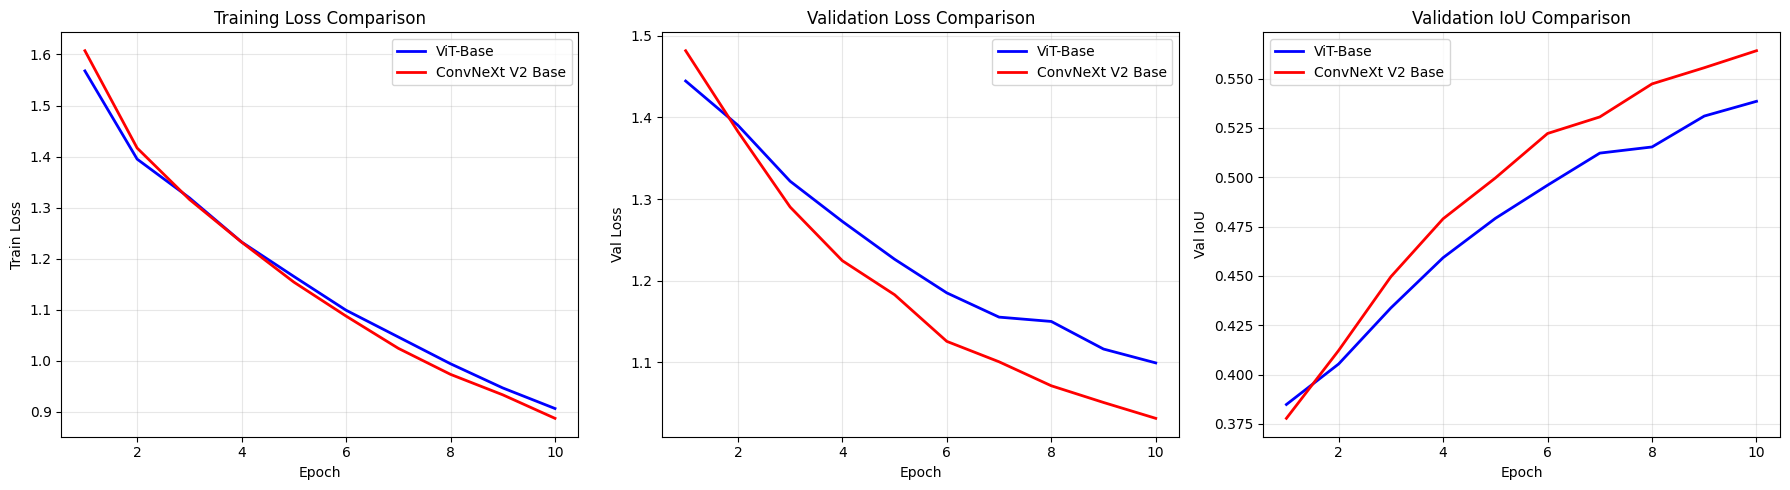


Final Results:
ViT-Base: IoU=0.5385
ConvNeXt V2 Base: IoU=0.5642


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, config.num_epochs + 1)

# Training loss
axes[0].plot(epochs, vit_history['train_loss'], 'b-', label='ViT-Base', linewidth=2)
axes[0].plot(epochs, convnext_history['train_loss'], 'r-', label='ConvNeXt V2 Base', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss
axes[1].plot(epochs, vit_history['val_loss'], 'b-', label='ViT-Base', linewidth=2)
axes[1].plot(epochs, convnext_history['val_loss'], 'r-', label='ConvNeXt V2 Base', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Validation IoU
axes[2].plot(epochs, vit_history['val_iou'], 'b-', label='ViT-Base', linewidth=2)
axes[2].plot(epochs, convnext_history['val_iou'], 'r-', label='ConvNeXt V2 Base', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Val IoU')
axes[2].set_title('Validation IoU Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vit_vs_convnext_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFinal Results:')
print(f"ViT-Base: IoU={vit_history['val_iou'][-1]:.4f}")
print(f"ConvNeXt V2 Base: IoU={convnext_history['val_iou'][-1]:.4f}")

## Inference Visualization

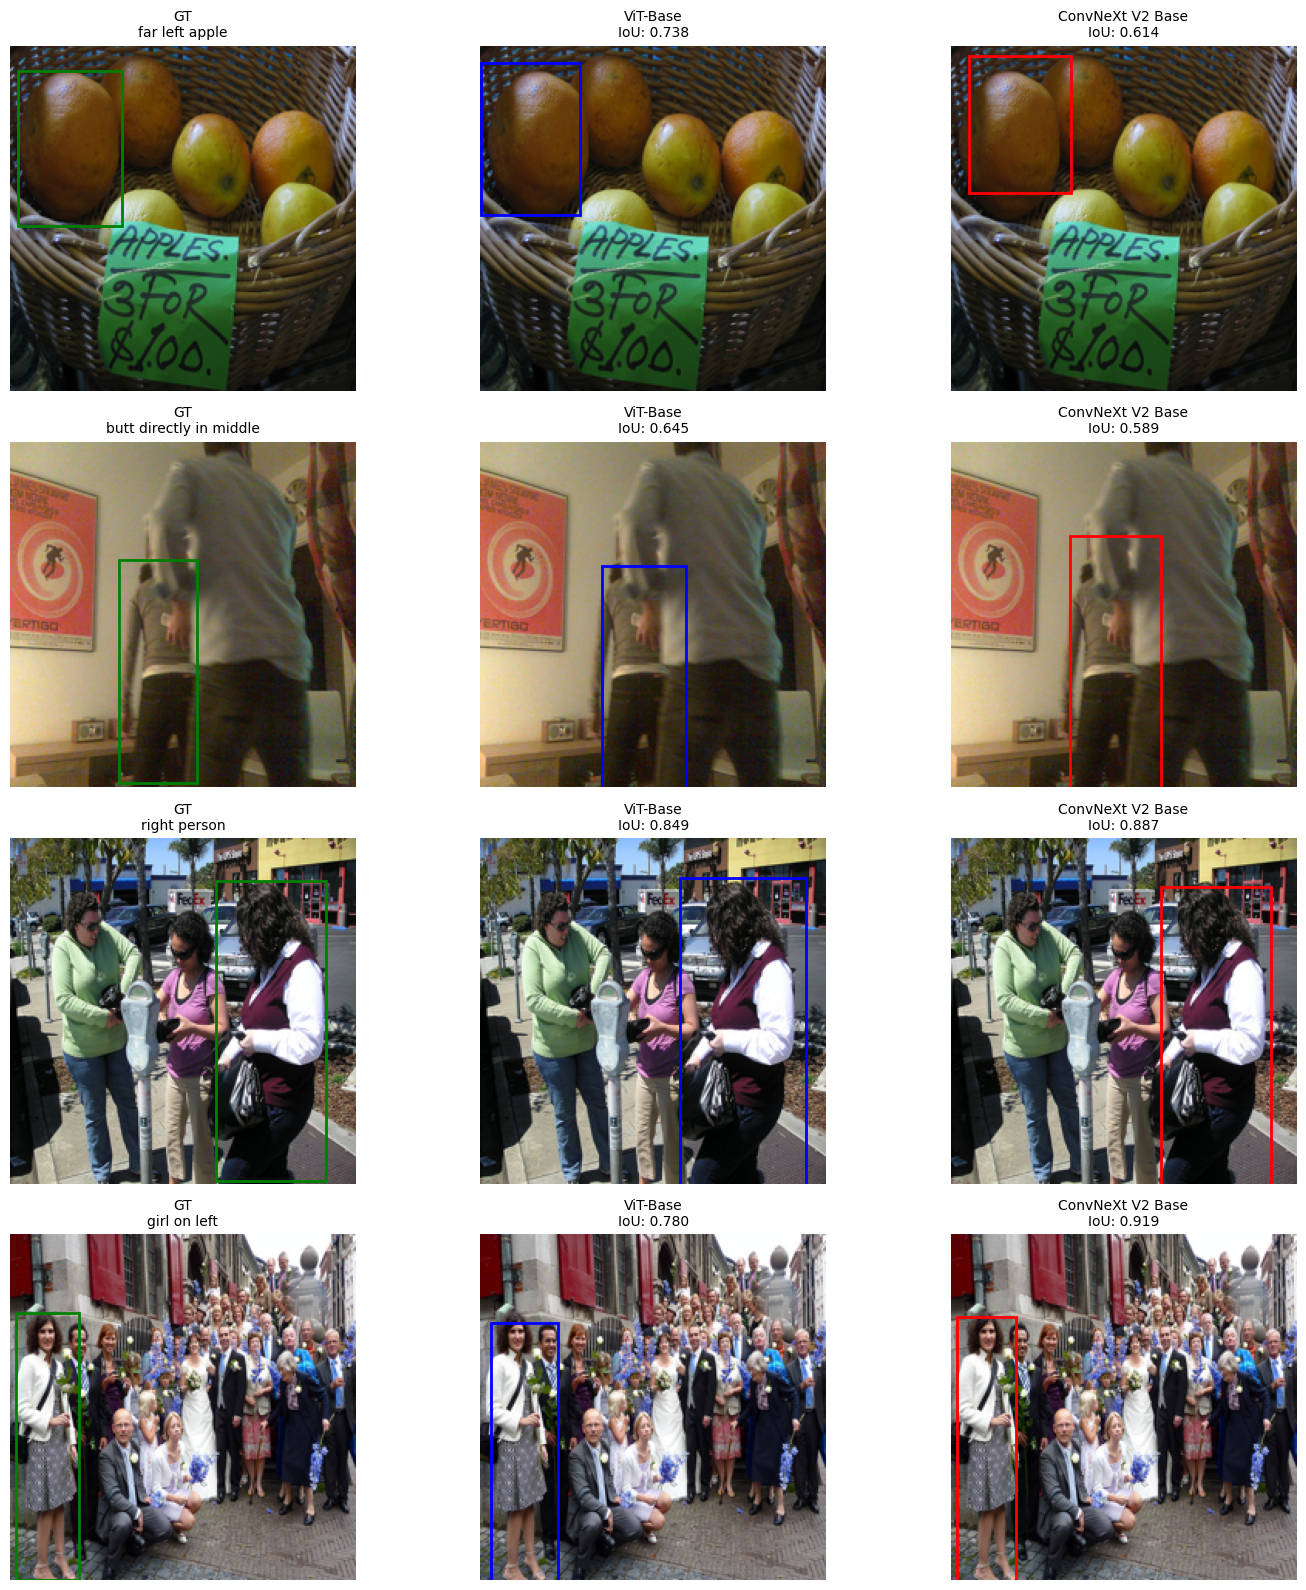

In [ ]:
# Visualize predictions from both models
def visualize_predictions(vit_model, convnext_model, dataset, num_samples=4):
    # Move models to GPU for inference
    vit_model = vit_model.to(device)
    convnext_model = convnext_model.to(device)

    vit_model.eval()
    convnext_model.eval()

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        sample = dataset[idx]

        # Prepare input
        image = sample['image'].unsqueeze(0).to(device)
        input_ids = sample['input_ids'].unsqueeze(0).to(device)
        attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
        gt_bbox_xyxy = sample['bbox'].numpy()  # GT is in xyxy format

        # Get predictions (in xywh format)
        with torch.no_grad():
            vit_pred_xywh = vit_model(image, input_ids, attention_mask)[0]
            convnext_pred_xywh = convnext_model(image, input_ids, attention_mask)[0]

            # Convert predictions to xyxy for visualization and IoU computation
            vit_pred_xyxy = xywh2xyxy(vit_pred_xywh.unsqueeze(0))[0]
            convnext_pred_xyxy = xywh2xyxy(convnext_pred_xywh.unsqueeze(0))[0]

            # Sanitize predictions
            vit_pred_xyxy = sanitize_xyxy(vit_pred_xyxy.unsqueeze(0))[0].cpu().numpy()
            convnext_pred_xyxy = sanitize_xyxy(convnext_pred_xyxy.unsqueeze(0))[0].cpu().numpy()

        # Denormalize image for visualization
        img = sample['image'].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)

        # Plot Ground Truth
        axes[i, 0].imshow(img)
        x1, y1, x2, y2 = gt_bbox_xyxy * config.img_size
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='green', facecolor='none')
        axes[i, 0].add_patch(rect)
        axes[i, 0].set_title(f'GT\n{sample["text"][:40]}', fontsize=10)
        axes[i, 0].axis('off')

        # Plot ViT prediction
        axes[i, 1].imshow(img)
        x1, y1, x2, y2 = vit_pred_xyxy * config.img_size
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='blue', facecolor='none')
        axes[i, 1].add_patch(rect)
        vit_iou = compute_iou(
            torch.tensor([vit_pred_xyxy]),
            torch.tensor([gt_bbox_xyxy])
        )[0].item()
        axes[i, 1].set_title(f'ViT-Base\nIoU: {vit_iou:.3f}', fontsize=10)
        axes[i, 1].axis('off')

        # Plot ConvNeXt prediction
        axes[i, 2].imshow(img)
        x1, y1, x2, y2 = convnext_pred_xyxy * config.img_size
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
        axes[i, 2].add_patch(rect)
        convnext_iou = compute_iou(
            torch.tensor([convnext_pred_xyxy]),
            torch.tensor([gt_bbox_xyxy])
        )[0].item()
        axes[i, 2].set_title(f'ConvNeXt V2 Base\nIoU: {convnext_iou:.3f}', fontsize=10)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('inference_comparison.png', dpi=150, bbox_inches='tight')

    plt.show()

visualize_predictions(vit_model, convnext_model, val_dataset, num_samples=4)